In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdFMCS
from rdkit.Chem import rdDistGeom
from rdkit.Chem import rdChemReactions
from IPython.display import display
import mols2grid

In [2]:
def convert_3d_adducts_to_2d(sdf_file_path, reverse_reaction_smarts_list, remove_stereochemistry=False):
    """
    Reads 3D adducts from SDF, applies reverse transformations to restore 
    the pre-reaction 2D structures, and removes duplicates.
    """
    # Pre-compile reactions for performance
    reactions = [rdChemReactions.ReactionFromSmarts(smarts) for smarts in reverse_reaction_smarts_list]
    
    # Read 3D SDF file, remove hydrogens
    suppl = Chem.SDMolSupplier(sdf_file_path, removeHs=True)
    
    seen_smiles = set()
    
    for mol in suppl:
        if mol is None:
            continue

        try:
            Chem.SanitizeMol(mol)
        except:
            continue

        # Try to find a matching reverse reaction
        product = None
        for rxn in reactions:
            try:
                results = rxn.RunReactants((mol,))
                if results:
                    # Take the first product of the first outcome
                    product = results[0][0]
                    # Update property cache to ensure connectivity is clean
                    product.UpdatePropertyCache(strict=False)
                    break
            except Exception:
                continue
        
        if product:
            try:
                # Sanitize and normalize and 2D the product
                Chem.SanitizeMol(product)
                AllChem.Compute2DCoords(product)

                # Remove stereochemistry only if explicitly requested
                if remove_stereochemistry:
                    Chem.RemoveStereochemistry(product)
                
                # Check for uniqueness using isomeric SMILES (preserves stereo if not removed)
                smiles = Chem.MolToSmiles(product, isomericSmiles=True)
                if smiles not in seen_smiles:
                    seen_smiles.add(smiles)
                    
            except Exception:
                continue

    print(f'Total number of unique 2D precursors: {len(seen_smiles)}')
    unique_mols = [Chem.MolFromSmiles(i) for i in seen_smiles]

    return unique_mols

In [3]:
reaction_smarts_list = [
'[#6:0]=[#6]-[#6](=[#8])-[#7](-[#6])-[*:1]>>[#6]-[#6]-[#16]-[#6:0]-[#6]-[#6](=[#8])-[#7](-[#6])-[*:1]',
'[*:1]-[#7]-[#6](=[#8])-[#6:2]-[#17:0]>>[*:1]-[#7]-[#6](=[#8])-[#6:2]-[#16]-[#6]-[#6]',
'[*:1]-[#6]1-[#6:0]-[#8]-1>>[*:1]-[#6](-[#8])-[#6:0](-[#16]-[#6]-[#6])',
'[#6:0]=[#6]-[#16](-[*:1])(=[#8])=[#8]>>[#8]=[#16](-[*:1])(=[#8])-[#6]-[#6:0]-[#16]-[#6]-[#6]',
'[#6:0]=[#6](-[#6]#[#7])-[#6](=[#8])-[#7](-[#6])-[*:1]>>[#6]-[#6]-[#16]-[#6:0]-[#6](-[#6]#[#7])-[#6](=[#8])-[#7](-[#6])-[*:1]',
'[#6:2]-[#6:0]#[#6]-[#6](=[#8])-[#7](-[#6])-[*:1]>>[#6]-[#6]-[#16]-[#6:0](-[#6:2])=[#6]-[#6](=[#8])-[#7](-[#6])-[*:1]',
'[#7:2]#[#6:0]-[#7:3]1-[#6]-[#6]-[#6](-[*:1])-[#6]-[#6]-1>>[#7:2]=[#6:0](-[#16]-[#6]-[#6])-[#7:3]1-[#6]-[#6]-[#6](-[*:1])-[#6]-[#6]-1',
'[#7:2]#[#6:0]-[#7:3]1-[#6]-[#6](-[*:1])-[#6]-[#6]-[#6]-1>>[#7:2]=[#6:0](-[#16]-[#6]-[#6])-[#7:3]1-[#6]-[#6](-[*:1])-[#6]-[#6]-[#6]-1',
'[#7:2]#[#6:0]-[#7:3]1-[#6]-[#6](-[*:1])-[#6]-[#6]-1>>[#7:2]=[#6:0](-[#16]-[#6]-[#6])-[#7:3]1-[#6]-[#6](-[*:1])-[#6]-[#6]-1',
'[#9:0]-[#16:1](=[#8:2])(=[#8:3])-[*:4]>>[#6]-[#6]-[#6]1:[#7]:[#6]:[#7](-[#16:1](=[#8:2])(=[#8:3])-[*:4]):[#6]:1'
]

In [4]:
def get_reverse_smarts(smarts):
    # Split into reactants and products. Assumes standard SMARTS reaction format with ">>"
    parts = smarts.split(">>")
    if len(parts) == 2:
        return f"{parts[1]}>>{parts[0]}"
    return smarts

reverse_reaction_smarts_list = [get_reverse_smarts(rxn) for rxn in reaction_smarts_list]

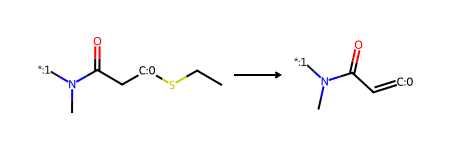

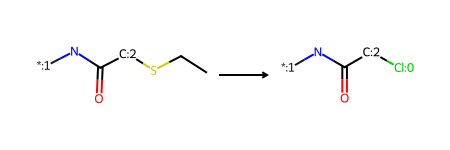

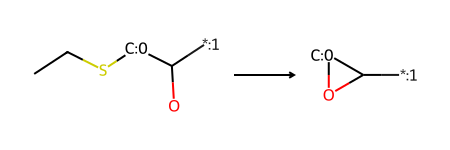

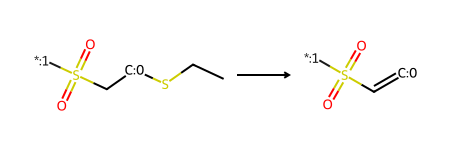

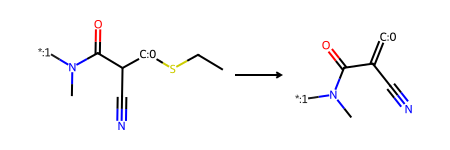

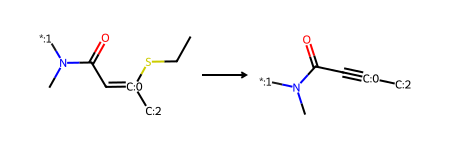

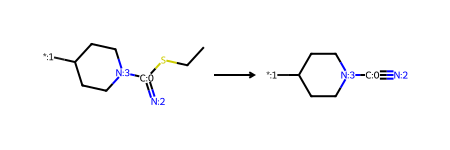

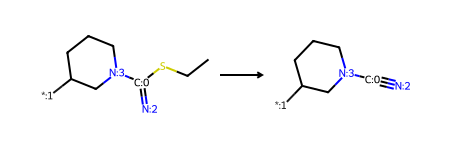

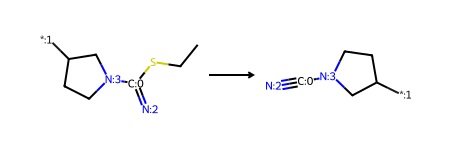

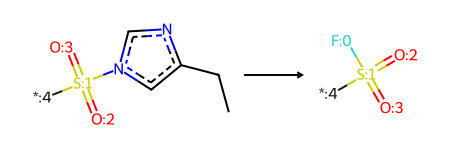

In [5]:
reversed_reactions = [rdChemReactions.ReactionFromSmarts(rxn) for rxn in reverse_reaction_smarts_list]
for i in range(len(reversed_reactions)):
    display(reversed_reactions[i])

In [6]:
test_mols = convert_3d_adducts_to_2d('../covalent_docking_test/covalent_binders_filtered_minus_7.5_MW500_NROT10_unique.sdf', reverse_reaction_smarts_list, remove_stereochemistry=True)
binary_mols = convert_3d_adducts_to_2d('binary/covalent_binders_filtered_minus_10_MW500_NROT7_unique.sdf', reverse_reaction_smarts_list, remove_stereochemistry=True)
IKZF2_mols = convert_3d_adducts_to_2d('IKZF2/covalent_binders_filtered_minus_11_MW550_NROT8_unique.sdf', reverse_reaction_smarts_list, remove_stereochemistry=True)
WIZ_mols = convert_3d_adducts_to_2d('WIZ/covalent_binders_filtered_minus_12.5_MW550_NROT7_unique.sdf', reverse_reaction_smarts_list, remove_stereochemistry=True)
all_mols = test_mols + binary_mols + IKZF2_mols + WIZ_mols
print(len(all_mols))
#remove duplicates again just in case
unique_smiles = set()
unique_mols = []
for mol in all_mols:
    smiles = Chem.MolToSmiles(mol, isomericSmiles=True)
    if smiles not in unique_smiles:
        unique_smiles.add(smiles)
        unique_mols.append(mol)
print(len(unique_mols))
mols2grid.display(unique_mols)

[12:21:39] product atom-mapping number 0 not found in reactants.
[12:21:39] product atom-mapping number 0 not found in reactants.
[12:21:39] product atom-mapping number 0 not found in reactants.
[12:21:39] product atom-mapping number 0 not found in reactants.


Total number of unique 2D precursors: 33
Total number of unique 2D precursors: 935


[12:21:41] product atom-mapping number 0 not found in reactants.
[12:21:41] product atom-mapping number 0 not found in reactants.


Total number of unique 2D precursors: 696


[12:21:42] product atom-mapping number 0 not found in reactants.


Total number of unique 2D precursors: 2776
4440
4436


In [7]:
import pandas as pd
from rdkit.Chem import QED

#dataframe to hold QED scores
qed_scores = []
for mol in unique_mols:
    qed = QED.qed(mol)
    qed_scores.append(qed)

pdqed = pd.DataFrame({'SMILES': [Chem.MolToSmiles(mol, isomericSmiles=True) for mol in unique_mols], 'QED': qed_scores})
pdqed = pdqed.sort_values(by='QED', ascending=False)
pdqed.reset_index(drop=True, inplace=True)
pdqed

,SMILES,QED
0,O=C1CCN(C2CCc3c(cccc3OS(=O)(=O)F)C2)C(=O)N1,0.829915
1,O=C1CCN(C2CCc3cc(OS(=O)(=O)F)ccc3C2)C(=O)N1,0.829915
2,O=C1CCN(C2CCc3ccc(OS(=O)(=O)F)cc3C2)C(=O)N1,0.829915
3,O=C1CCN(c2ccc(OS(=O)(=O)F)cc2)C(=O)N1,0.827441
4,O=C1CCN(C2CCc3ccc(S(=O)(=O)F)cc3C2)C(=O)N1,0.826333
...,...,...
4431,O=C1CCC(Sc2nc(S(=O)(=O)F)nc3c2oc2ccccc23)C(=O)N1,0.309199
4432,O=C1CCC(NC(=O)c2cccc3c(=O)c4cc(OS(=O)(=O)F)ccc...,0.304046
4433,O=C1CCC(N2Cc3ccc(Nc4nc(S(=O)(=O)F)nc5[nH]ccc45...,0.298538
4434,O=C1CCC(N2Cc3ccc(Nc4nc(S(=O)(=O)F)nc5cc[nH]c45...,0.298538


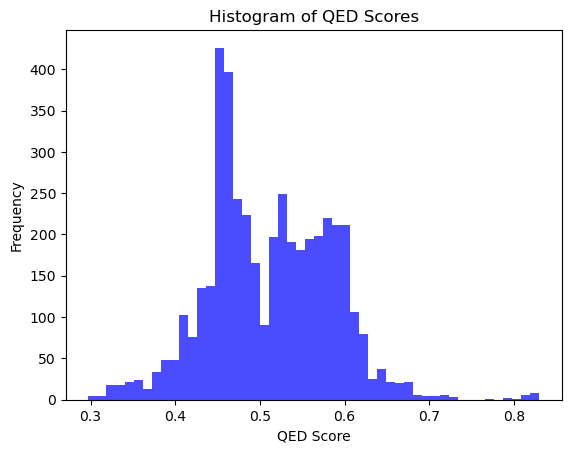

In [8]:
#histrogram of QED scores
import matplotlib.pyplot as plt
plt.hist(pdqed['QED'], bins=50, color='blue', alpha=0.7)
plt.title('Histogram of QED Scores')
plt.xlabel('QED Score')
plt.ylabel('Frequency')
plt.show()

In [18]:
df = pdqed[pdqed['QED']>0.5]
df2 = pdqed[(pdqed['QED']<=0.5) & (pdqed['QED']>0.49)]

In [19]:
df.to_csv('covalent_docking_unique_2D_precursors_QED_filtered_above_05.csv', index=False)
df2.to_csv('covalent_docking_unique_2D_precursors_QED_filtered_above_049.csv', index=False)